# 11 - TransXion and AMLNet Stress-Test Synthesis

Notebook này tổng hợp hậu nghiệm hai stress test đã khóa. Nó không train model, không audit
lại rule và không chọn lại policy. Hãy Add Input hai Kaggle version outputs của Notebook 09
và 10. Mọi artifact phải qua checksum lineage trước khi được đưa vào bảng khóa luận.

In [1]:
from pathlib import Path
from importlib import metadata as importlib_metadata
import importlib
import importlib.util
import json
import os
import subprocess
import sys

from packaging.requirements import Requirement
from packaging.utils import canonicalize_name

KAGGLE = Path("/kaggle").exists()
REPO_URL = "https://github.com/Tommyhuy1705/Explainable_NeuroSymbolic_Fraud_Detection.git"
BRANCH = "main"
KAGGLE_PROJECT_DIR = Path("/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection")

def sync_project() -> Path:
    if KAGGLE:
        if not KAGGLE_PROJECT_DIR.exists():
            subprocess.run(
                ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(KAGGLE_PROJECT_DIR)],
                check=True,
            )
        elif not (KAGGLE_PROJECT_DIR / ".git").is_dir():
            raise RuntimeError(f"Expected a Git clone at {KAGGLE_PROJECT_DIR}")
        else:
            subprocess.run(
                ["git", "-C", str(KAGGLE_PROJECT_DIR), "pull", "--ff-only", "origin", BRANCH],
                check=True,
            )
        return KAGGLE_PROJECT_DIR.resolve()
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Run this notebook inside the project or on Kaggle with Internet enabled")

PROJECT_ROOT = sync_project()
while str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

# A Kaggle kernel may survive a previous run. Never execute a stale src module.
for module_name in tuple(sys.modules):
    if module_name == "src" or module_name.startswith("src."):
        del sys.modules[module_name]

QUICK_RUN = os.getenv("THESIS_STRESS_QUICK_RUN", "0") == "1"
USE_TEST_FIXTURE = os.getenv("THESIS_STRESS_TEST_FIXTURE", "0") == "1"
if USE_TEST_FIXTURE and not QUICK_RUN:
    raise ValueError("THESIS_STRESS_TEST_FIXTURE=1 requires THESIS_STRESS_QUICK_RUN=1")
STRICT_RUNTIME_REQUIREMENTS = not (QUICK_RUN and USE_TEST_FIXTURE)

OUTPUT_BASE = (
    Path("/kaggle/working/thesis_stress_outputs")
    if KAGGLE else PROJECT_ROOT / "results/stress/notebooks"
)
DATA_ROOTS = [Path("/kaggle/input")] if KAGGLE else [PROJECT_ROOT / "data/raw"]

RUNTIME_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scikit-learn": "sklearn",
    "scipy": "scipy",
    "pyyaml": "yaml",
    "joblib": "joblib",
    "torch": "torch",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
}

declared_requirements = {}
for raw_line in (PROJECT_ROOT / "requirements.txt").read_text(encoding="utf-8").splitlines():
    requirement_text = raw_line.split("#", maxsplit=1)[0].strip()
    if not requirement_text:
        continue
    requirement = Requirement(requirement_text)
    normalized_name = canonicalize_name(requirement.name)
    if normalized_name in RUNTIME_IMPORTS:
        declared_requirements[normalized_name] = requirement
missing_declarations = sorted(set(RUNTIME_IMPORTS).difference(declared_requirements))
if missing_declarations:
    raise RuntimeError(
        "requirements.txt has no declared range for runtime packages: "
        + ", ".join(missing_declarations)
    )

def runtime_package_status(package_name):
    requirement = declared_requirements[package_name]
    import_name = RUNTIME_IMPORTS[package_name]
    if importlib.util.find_spec(import_name) is None:
        return "missing", None, requirement
    try:
        installed_version = importlib_metadata.version(requirement.name)
    except importlib_metadata.PackageNotFoundError:
        installed_version = None
    # Vendor-managed Torch images can expose a fully usable import while the
    # distribution metadata has no Version field. Torch is never repaired in
    # this notebook, so reading its runtime version cannot create a stale
    # import after pip installation.
    if not installed_version and package_name == "torch":
        torch_module = importlib.import_module(import_name)
        installed_version = str(getattr(torch_module, "__version__", "")).strip() or None
    if not installed_version:
        return "metadata_missing", None, requirement
    if installed_version not in requirement.specifier:
        return "out_of_range", installed_version, requirement
    return "ok", installed_version, requirement

runtime_status = {
    package_name: runtime_package_status(package_name)
    for package_name in RUNTIME_IMPORTS
}
torch_status, torch_version, torch_requirement = runtime_status["torch"]
if torch_status != "ok" and STRICT_RUNTIME_REQUIREMENTS:
    observed = torch_version if torch_version is not None else torch_status
    raise ImportError(
        f"PyTorch environment is incompatible: observed {observed!r}, required "
        f"{torch_requirement}. Select a Kaggle image whose preinstalled Torch/CUDA wheel "
        "satisfies this range; this notebook will not install, upgrade, downgrade, or replace Torch."
    )

repair_requirements = [
    str(requirement)
    for package_name, (status, _, requirement) in runtime_status.items()
    if package_name != "torch" and status != "ok"
]
if repair_requirements and KAGGLE and STRICT_RUNTIME_REQUIREMENTS:
    # --no-deps ensures this repair cannot replace Kaggle's preinstalled
    # Torch/CUDA wheel indirectly through dependency resolution.
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--upgrade",
            "--no-deps",
            *repair_requirements,
        ],
        check=True,
    )
    importlib.invalidate_caches()
    runtime_status = {
        package_name: runtime_package_status(package_name)
        for package_name in RUNTIME_IMPORTS
    }

invalid_packages = {
    package_name: {
        "status": status,
        "installed_version": installed_version,
        "required": str(requirement),
    }
    for package_name, (status, installed_version, requirement) in runtime_status.items()
    if status != "ok"
}
RUNTIME_REQUIREMENTS_VALID = not invalid_packages
if invalid_packages and STRICT_RUNTIME_REQUIREMENTS:
    raise ImportError(
        "Runtime packages do not satisfy requirements.txt: "
        + json.dumps(invalid_packages, sort_keys=True)
    )
RUNTIME_PACKAGE_VERSIONS = {
    declared_requirements[package_name].name: installed_version
    for package_name, (_, installed_version, _) in runtime_status.items()
}
if invalid_packages and not STRICT_RUNTIME_REQUIREMENTS:
    print(
        "Engineering fixture warning: runtime packages are outside the declared "
        "ranges. This run is claim-ineligible by construction: "
        + json.dumps(invalid_packages, sort_keys=True)
    )

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"], text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    GIT_COMMIT = None

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)
print({
    "project_root": str(PROJECT_ROOT),
    "git_commit": GIT_COMMIT,
    "quick_run": QUICK_RUN,
    "test_fixture": USE_TEST_FIXTURE,
    "claim_eligible_mode": not QUICK_RUN and not USE_TEST_FIXTURE,
    "strict_runtime_requirements": STRICT_RUNTIME_REQUIREMENTS,
    "runtime_requirements_valid": RUNTIME_REQUIREMENTS_VALID,
    "runtime_package_versions": RUNTIME_PACKAGE_VERSIONS,
})

Cloning into '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection'...


{'project_root': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection', 'git_commit': 'afa38f3cb7cd70fe36fd39cb5ce34ab314b04e28', 'quick_run': False, 'test_fixture': False, 'claim_eligible_mode': True, 'strict_runtime_requirements': True, 'runtime_requirements_valid': True, 'runtime_package_versions': {'numpy': '2.0.2', 'pandas': '2.3.3', 'scikit-learn': '1.6.1', 'scipy': '1.16.3', 'PyYAML': '6.0.3', 'joblib': '1.5.3', 'torch': '2.10.0+cpu', 'xgboost': '3.2.0', 'lightgbm': '4.6.0'}}


## 1. Discover exactly one valid artifact for each stress dataset

In [2]:
from src.stress_testing.artifacts import find_unique_stress_manifest, validate_stress_lineage

SEARCH_ROOTS = [Path("/kaggle/input")] if KAGGLE else [OUTPUT_BASE]
manifest_paths = {
    "transxion_v2": find_unique_stress_manifest("transxion_v2", SEARCH_ROOTS),
    "amlnet_v1_0": find_unique_stress_manifest("amlnet_v1_0", SEARCH_ROOTS),
}
manifests = {}
for dataset, manifest_path in manifest_paths.items():
    lineage_path = manifest_path.with_name("stress_lineage.json")
    validate_stress_lineage(lineage_path, expected_dataset_manifest=manifest_path)
    manifests[dataset] = json.loads(manifest_path.read_text(encoding="utf-8"))
    print(dataset, manifest_path, "lineage=valid")

transxion_v2 /kaggle/input/notebooks/giahuytranviet/09-transxion-v2-stress-test/thesis_stress_outputs/09_transxion_v2_stress_test/stress_test_manifest.json lineage=valid
amlnet_v1_0 /kaggle/input/notebooks/giahuytranviet/10-amlnet-v1-0-stress-test/thesis_stress_outputs/10_amlnet_v1_0_stress_test/stress_test_manifest.json lineage=valid


## 2. Claim eligibility and source identity gate

In [3]:
CORE_ENVIRONMENT_PACKAGES = (
    "numpy",
    "pandas",
    "scikit-learn",
    "scipy",
    "xgboost",
    "lightgbm",
    "torch",
)

def manifest_core_environment(payload):
    environment = payload.get("environment")
    if not isinstance(environment, dict):
        raise ValueError("Stress manifest is missing its captured environment")
    python_runtime = str(environment.get("python") or "").strip()
    packages = environment.get("packages")
    if not python_runtime or not isinstance(packages, dict):
        raise ValueError(
            "Stress manifest must record Python and core package versions"
        )
    signature = {"python": python_runtime.split()[0]}
    for package_name in CORE_ENVIRONMENT_PACKAGES:
        version = packages.get(package_name)
        if version is None or not str(version).strip():
            raise ValueError(
                f"Stress manifest is missing version metadata for {package_name}"
            )
        signature[package_name] = str(version).strip()
    return signature

upstream_core_environments = {
    dataset: manifest_core_environment(payload)
    for dataset, payload in manifests.items()
}
serialized_environments = {
    json.dumps(environment, sort_keys=True)
    for environment in upstream_core_environments.values()
}
if len(serialized_environments) != 1:
    raise ValueError(
        "Notebook 09/10 artifacts must use matching Python and core package versions: "
        + json.dumps(upstream_core_environments, sort_keys=True)
    )
MATCHED_UPSTREAM_CORE_ENVIRONMENT = next(
    iter(upstream_core_environments.values())
)
CURRENT_CORE_ENVIRONMENT = {
    "python": sys.version.split()[0],
    **{
        package_name: RUNTIME_PACKAGE_VERSIONS[package_name]
        for package_name in CORE_ENVIRONMENT_PACKAGES
    },
}

eligibility = pd.DataFrame([
    {
        "dataset": dataset,
        "claim_eligible": payload["claim_eligible"],
        "claim_blockers": ";".join(payload["claim_blockers"]),
        "git_commit": payload["git_commit"],
        "pipeline_fingerprint": payload["stress_pipeline_fingerprint"],
        "source_fingerprint": payload["stress_source_fingerprint"],
        "core_environment": json.dumps(
            upstream_core_environments[dataset], sort_keys=True
        ),
        "source_checksum_verified": all(
            record.get("verified", False)
            for record in payload["data_manifest"]["source_files"]
            if record.get("role", "transactions") != "profile"
        ),
    }
    for dataset, payload in manifests.items()
])
display(eligibility)
if not eligibility["claim_eligible"].all() and not (QUICK_RUN and USE_TEST_FIXTURE):
    raise ValueError("At least one stress artifact is not eligible for thesis claims")
if not eligibility["claim_eligible"].all():
    display(Markdown(
        "**Engineering smoke only:** upstream fixture/quick artifacts are intentionally "
        "ineligible and this synthesis must not be used in the thesis results."
    ))
upstream_commits = eligibility["git_commit"].fillna("").astype(str).str.strip()
if upstream_commits.eq("").any():
    raise ValueError(
        "Every Notebook 09/10 artifact must record a non-null Git commit"
    )
source_fingerprints = set(
    eligibility["source_fingerprint"].fillna("").astype(str).str.strip()
)
source_fingerprints.discard("")
if len(source_fingerprints) != 1:
    raise ValueError(
        "Notebook 09/10 artifacts must use one non-null executable source fingerprint"
    )
MATCHED_STRESS_SOURCE_FINGERPRINT = next(iter(source_fingerprints))

,dataset,claim_eligible,claim_blockers,git_commit,pipeline_fingerprint,source_fingerprint,core_environment,source_checksum_verified
0,transxion_v2,True,,bbd02b17a1ce7499dab1043fdc24c13bed4cae42,67dc006b615320d280e1a0870a042ffe8dcc7c57eb3daa1c4a4e2e45f932267d,e9b31d84ea33f4c5a3b3fca1002bd7f06e21cbe1bd74765f054e4122454ce87a,"{""lightgbm"": ""4.6.0"", ""numpy"": ""2.0.2"", ""pandas"": ""2.3.3"", ""python"": ""3.12.13"", ""scikit-learn"": ""1.6.1"", ""scipy"": ""1.16.3"", ""torch"": ""2.10.0+cu128"", ""xgboos...",True
1,amlnet_v1_0,True,,83c50199a2d27f49e75801020ddef9c436acfa0b,3f8d4a53966b41d3ed6a283e291a835302c45f9318000f2f096fcdf2bc4686fd,e9b31d84ea33f4c5a3b3fca1002bd7f06e21cbe1bd74765f054e4122454ce87a,"{""lightgbm"": ""4.6.0"", ""numpy"": ""2.0.2"", ""pandas"": ""2.3.3"", ""python"": ""3.12.13"", ""scikit-learn"": ""1.6.1"", ""scipy"": ""1.16.3"", ""torch"": ""2.10.0+cu128"", ""xgboos...",True


## 3. Read locked outputs without re-selection

In [4]:
def read_table(dataset, filename):
    return pd.read_csv(manifest_paths[dataset].parent / filename).assign(dataset=dataset)

def read_json_artifact(dataset, filename):
    return json.loads(
        (manifest_paths[dataset].parent / filename).read_text(encoding="utf-8")
    )

coverage = pd.concat(
    [read_table(dataset, "coverage_results.csv") for dataset in manifest_paths],
    ignore_index=True,
)
predictive = pd.concat(
    [read_table(dataset, "predictive_metrics.csv") for dataset in manifest_paths],
    ignore_index=True,
)
matched = pd.concat(
    [read_table(dataset, "matched_risk_results.csv") for dataset in manifest_paths],
    ignore_index=True,
)
bootstrap = pd.concat(
    [read_table(dataset, "paired_bootstrap.csv") for dataset in manifest_paths],
    ignore_index=True,
)
controls = pd.concat(
    [read_table(dataset, "negative_controls.csv") for dataset in manifest_paths],
    ignore_index=True,
)
outcomes = pd.concat(
    [read_table(dataset, "stress_outcomes.csv") for dataset in manifest_paths],
    ignore_index=True,
)
residual = pd.concat(
    [read_table(dataset, "residual_evidence.csv") for dataset in manifest_paths],
    ignore_index=True,
)
ablations = pd.concat(
    [read_table(dataset, "ablation_results.csv") for dataset in manifest_paths],
    ignore_index=True,
)
predictor_sensitivity = pd.concat(
    [read_table(dataset, "predictor_explanation_sensitivity.csv") for dataset in manifest_paths],
    ignore_index=True,
)
contrastive_status = pd.DataFrame([
    {
        "dataset": dataset,
        "contrastive_meta_available": bool(
            read_json_artifact(dataset, "contrastive_meta_provenance.json")["available"]
        ),
        "contrastive_meta_fallback_reason": read_json_artifact(
            dataset, "contrastive_meta_provenance.json"
        ).get("fallback_reason"),
        "contrastive_meta_fit_partition": read_json_artifact(
            dataset, "contrastive_meta_provenance.json"
        )["fit_partition"],
    }
    for dataset in manifest_paths
])
display(predictive)
display(contrastive_status)

,evaluation_partition,family,backend,seed,reference_selected,selection_split_pr_auc,n_rows,n_positive,prevalence,pr_auc,roc_auc,f2,precision,recall,recall_at_1pct_fpr,brier,ece,nll,threshold,predicted_positive_rate,target_fpr,null_prevalence,null_pr_auc,null_roc_auc,null_f2,null_precision,null_recall,null_recall_at_1pct_fpr,null_brier,null_ece,null_nll,pr_auc_lift_over_null,f2_lift_over_null,brier_improvement_over_null,nll_improvement_over_null,dataset
0,test,xgboost,xgboost,42,True,0.409376,605834.0,902.0,0.001489,0.353898,0.991095,0.570395,0.344924,0.681818,0.963415,0.001069,0.000172,0.003802,0.313953,0.002943,0.01,0.001489,0.001489,0.5,0.007400,0.001489,1.0,0.0,0.001487,1.301043e-18,0.011180,0.352409,0.562995,0.000418,0.007378,transxion_v2
1,test,lightgbm,lightgbm,42,False,0.111064,605834.0,902.0,0.001489,0.120365,0.880425,0.424076,0.157520,0.735033,0.767184,0.001333,0.000369,0.007076,0.000297,0.006947,0.01,0.001489,0.001489,0.5,0.007400,0.001489,1.0,0.0,0.001487,1.301043e-18,0.011180,0.118876,0.416676,0.000154,0.004104,transxion_v2
2,test,tabular_resnet_v2,torch,42,False,0.153859,605834.0,902.0,0.001489,0.122188,0.898469,0.350764,0.144795,0.544346,0.626386,0.001383,0.000227,0.007798,0.077320,0.005597,0.01,0.001489,0.001489,0.5,0.007400,0.001489,1.0,0.0,0.001487,1.301043e-18,0.011180,0.120700,0.343364,0.000104,0.003381,transxion_v2
3,test,xgboost,xgboost,42,True,0.928884,218034.0,302.0,0.001385,0.948104,0.997817,0.849112,0.595436,0.950331,0.970199,0.000245,0.000247,0.001295,0.011753,0.002211,0.01,0.001385,0.001385,0.5,0.006887,0.001385,1.0,0.0,0.001383,0.000000e+00,0.010501,0.946719,0.842225,0.001138,0.009206,amlnet_v1_0
4,test,lightgbm,lightgbm,42,False,0.658392,218034.0,302.0,0.001385,0.770356,0.960017,0.797443,0.852518,0.784768,0.920530,0.000444,0.000425,0.002272,0.808824,0.001275,0.01,0.001385,0.001385,0.5,0.006887,0.001385,1.0,0.0,0.001383,0.000000e+00,0.010501,0.768970,0.790555,0.000939,0.008229,amlnet_v1_0
5,test,tabular_resnet_v2,torch,42,False,0.865674,218034.0,302.0,0.001385,0.899234,0.994454,0.832838,0.591966,0.927152,0.953642,0.000235,0.000111,0.001517,0.059701,0.002169,0.01,0.001385,0.001385,0.5,0.006887,0.001385,1.0,0.0,0.001383,0.000000e+00,0.010501,0.897849,0.825950,0.001148,0.008984,amlnet_v1_0


,dataset,contrastive_meta_available,contrastive_meta_fallback_reason,contrastive_meta_fit_partition
0,transxion_v2,True,None,rule_audit
1,amlnet_v1_0,True,None,rule_audit


## 4. Primary fixed-coverage comparison

,dataset,predictor,coverage_budget,method,abstain,abstention_reason,test_rows,alert_count,requested_selected_count,selected_count,realized_selected_count,support_shift_underfill,selected_positive_count,score_only_selected_count,score_only_positive_count,score_only_requested_budget_selected_count,score_only_requested_budget_positive_count,test_positive_count,alert_positive_count,unexplained_alert_count,explanation_coverage,requested_explanation_coverage,realized_explanation_coverage,score_only_realized_coverage,score_only_requested_budget_coverage,equal_count_score_only_comparison,abstention_rate,selected_recall_test_positives,selected_recall_alert_positives,score_only_recall_test_positives,score_only_recall_alert_positives,score_only_requested_budget_recall_test_positives,score_only_requested_budget_recall_alert_positives,all_alert_precision,selected_alert_precision,precision_gain_vs_all_alerts,alert_triage_lift,score_only_precision,score_only_requested_budget_precision,delta_vs_score_only,score_only_headroom,score_only_requested_budget_headroom,positive_region_fidelity,alert_conditional_rank_fidelity,residual_tp_fp_unadjusted,evidence_tp_mean,evidence_fp_mean,selected_rule_count_total,supported_alert_count,supported_alert_rate,unsupported_alert_count,unsupported_alert_rate,mean_active_selected_rule_count_alerts,mean_active_selected_rule_count_explained,mean_displayed_rule_count_explained,rule_activation_density_alerts,rule_sparsity_alerts,alert_rule_evidence_xor_rate_all_rows,contradiction_rate,evidence_without_alert_count,evidence_without_alert_rate
5,amlnet_v1_0,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,218034,482,49,0,0,True,0,0,0,49,49,302,287,482,0.0,0.10,0.0,0.0,0.101660,True,1.0,0.0,0.0,0.0,0.0,0.162252,0.170732,0.595436,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,0.5,NaN,0.0,0.0,0.0,1,203,0.421162,279,0.578838,0.421162,NaN,NaN,0.421162,0.578838,0.009494,0.009494,1791,0.898195
1,transxion_v2,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,605834,1783,179,0,0,True,0,0,0,179,86,902,615,1783,0.0,0.10,0.0,0.0,0.100393,True,1.0,0.0,0.0,0.0,0.0,0.095344,0.139837,0.344924,NaN,NaN,NaN,NaN,0.480447,NaN,NaN,0.519553,0.5,NaN,0.0,0.0,0.0,1,53,0.029725,1730,0.970275,0.029725,NaN,NaN,0.029725,0.970275,0.051196,0.051196,29286,0.998194
6,amlnet_v1_0,xgboost:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,218034,482,121,0,0,True,0,0,0,121,121,302,287,482,0.0,0.25,0.0,0.0,0.251037,True,1.0,0.0,0.0,0.0,0.0,0.400662,0.421603,0.595436,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,0.5,NaN,0.0,0.0,0.0,1,203,0.421162,279,0.578838,0.421162,NaN,NaN,0.421162,0.578838,0.009494,0.009494,1791,0.898195
2,transxion_v2,xgboost:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,605834,1783,446,0,0,True,0,0,0,446,183,902,615,1783,0.0,0.25,0.0,0.0,0.250140,True,1.0,0.0,0.0,0.0,0.0,0.202882,0.297561,0.344924,NaN,NaN,NaN,NaN,0.410314,NaN,NaN,0.589686,0.5,NaN,0.0,0.0,0.0,1,53,0.029725,1730,0.970275,0.029725,NaN,NaN,0.029725,0.970275,0.051196,0.051196,29286,0.998194


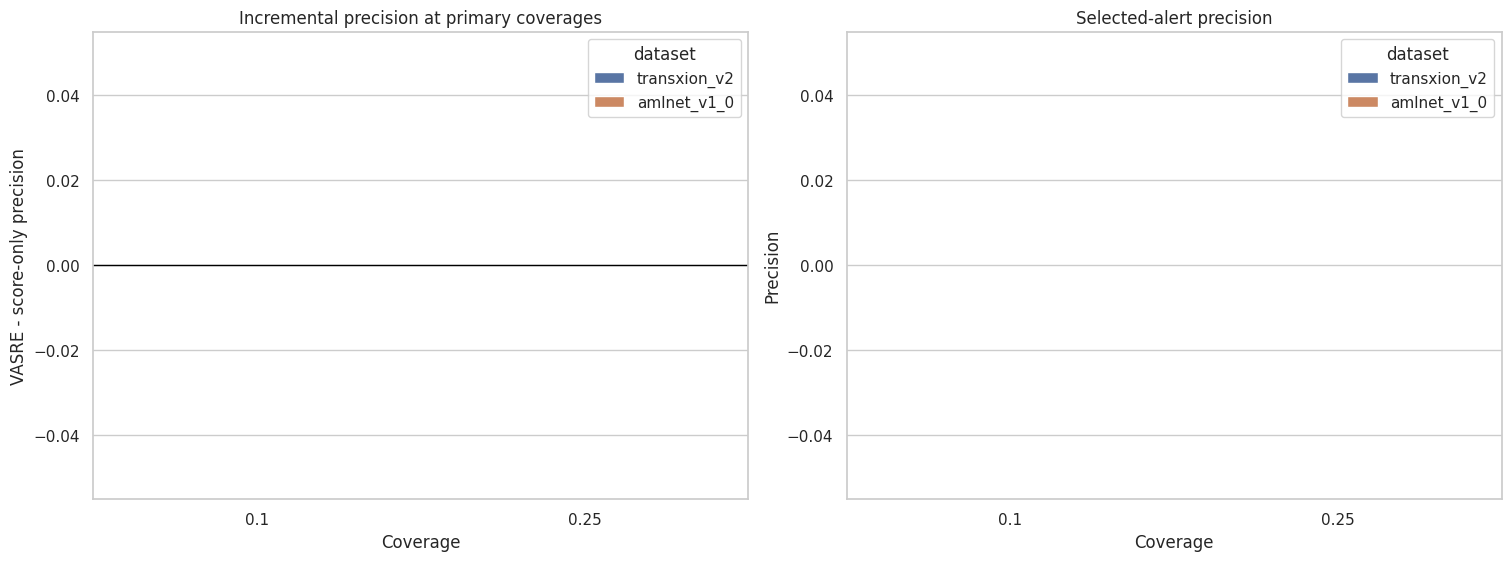

In [5]:
primary = coverage[coverage["coverage_budget"].round(2).isin([0.10, 0.25])].copy()
display(primary.sort_values(["coverage_budget", "dataset"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
sns.barplot(data=primary, x="coverage_budget", y="delta_vs_score_only", hue="dataset", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title="Incremental precision at primary coverages", xlabel="Coverage", ylabel="VASRE - score-only precision")
sns.barplot(data=primary, x="coverage_budget", y="selected_alert_precision", hue="dataset", ax=axes[1])
axes[1].set(title="Selected-alert precision", xlabel="Coverage", ylabel="Precision")
plt.show()

## 5. Uncertainty, matched-risk and negative-control evidence

In [6]:
display(bootstrap[bootstrap["coverage"].round(2).isin([0.10, 0.25])])
display(matched[matched["coverage_budget"].round(2).isin([0.10, 0.25])])
display(controls)
display(outcomes[outcomes["coverage_budget"].round(2).isin([0.10, 0.25])])
display(ablations[ablations["coverage_budget"].round(2).isin([0.10, 0.25])])
display(predictor_sensitivity[
    predictor_sensitivity["coverage_budget"].round(2).isin([0.10, 0.25])
])

bootstrap_primary = bootstrap[
    bootstrap["coverage"].round(2).isin([0.10, 0.25])
][[
    "dataset", "coverage", "ci_low", "ci_high", "valid_iterations",
    "probability_vasre_better", "outcome"
]].rename(columns={"outcome": "bootstrap_outcome"})
matched_primary = matched[
    matched["coverage_budget"].round(2).isin([0.10, 0.25])
][[
    "dataset", "coverage_budget", "matched_pairs", "match_rate",
    "mean_absolute_risk_gap", "matched_precision_difference",
    "matched_ci_low", "matched_ci_high"
]]
outcome_columns = [
    "dataset", "coverage_budget", "outcome", "risk_conditioned_tp_fp_gap",
    "positive_incremental_evidence_confirmed", "saturation_confirmed",
    "saturation_scope_eligible", "saturation_sample_adequate",
    "core_equal_count_score_only_comparison",
    "shuffled_control_comparison_valid",
    "shuffled_controls_below_locked_primary",
    "shuffled_controls_no_material_gain"
]
outcome_primary = outcomes[
    outcomes["coverage_budget"].round(2).isin([0.10, 0.25])
][[column for column in outcome_columns if column in outcomes]].rename(
    columns={"outcome": "stress_outcome"}
)
synthesis = primary.merge(
    bootstrap_primary,
    left_on=["dataset", "coverage_budget"],
    right_on=["dataset", "coverage"],
    how="left",
    validate="one_to_one",
).merge(
    matched_primary,
    on=["dataset", "coverage_budget"],
    how="left",
    validate="one_to_one",
).merge(
    outcome_primary,
    on=["dataset", "coverage_budget"],
    how="left",
    validate="one_to_one",
).merge(
    contrastive_status,
    on="dataset",
    how="left",
    validate="many_to_one",
)
display(synthesis)

,coverage,coverage_budget,outcome,preliminary_outcome,positive_confirmation_required,positive_incremental_evidence_confirmed,saturation_confirmation_required,saturation_confirmed,saturation_headroom_threshold,saturation_precision_margin,saturation_evidence_margin,minimum_positive_stability_fraction,minimum_saturation_alert_positives,minimum_saturation_matched_pairs,minimum_saturation_bootstrap_replicates,core_equal_count_score_only_comparison,negative_control_count_fair,mandatory_shuffled_control_names,shuffled_control_primary_realized_count,shuffled_control_primary_selected_precision,shuffled_control_rows_complete,shuffled_control_counts_match_primary,shuffled_control_metrics_finite,shuffled_control_comparison_valid,shuffled_control_max_selected_precision,shuffled_control_max_delta_vs_score_only,shuffled_controls_below_locked_primary,shuffled_controls_no_material_gain,shuffled_control_blockers,validation_label_shuffle_row_count,validation_label_shuffle_selected_count,validation_label_shuffle_score_only_selected_count,validation_label_shuffle_selected_precision,validation_label_shuffle_delta_vs_score_only,validation_weight_shuffle_row_count,validation_weight_shuffle_selected_count,validation_weight_shuffle_score_only_selected_count,validation_weight_shuffle_selected_precision,validation_weight_shuffle_delta_vs_score_only,observed_difference,bootstrap_mean_difference,ci_low,ci_high,probability_vasre_better,valid_iterations,bootstrap_unit,dataset
1,0.10,0.10,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,temporal_block,transxion_v2
2,0.25,0.25,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,temporal_block,transxion_v2
5,0.10,0.10,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,temporal_block,amlnet_v1_0
6,0.25,0.25,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,temporal_block,amlnet_v1_0


,coverage_budget,requested_selected_rows,matched_pairs,unmatched_rows,match_rate,mean_absolute_risk_gap,selected_precision,matched_control_precision,matched_precision_difference,matched_ci_low,matched_ci_high,probability_positive_difference,dataset
1,0.10,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,transxion_v2
2,0.25,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,transxion_v2
5,0.10,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,amlnet_v1_0
6,0.25,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,amlnet_v1_0


,coverage_budget,control,alert_count,requested_selected_count,matched_realized_selected_count,selected_count,equal_count_with_locked_vasre,achieved_alert_coverage,selected_precision,uses_test_labels_for_ranking,policy_abstained,dataset
0,0.05,locked_vasre,1783,90,0,0,True,0.0,NaN,False,True,transxion_v2
1,0.05,predictor_score_only,1783,90,0,0,True,0.0,NaN,False,True,transxion_v2
2,0.05,row_permuted_evidence,1783,90,0,0,True,0.0,NaN,False,True,transxion_v2
3,0.05,random_evidence,1783,90,0,0,True,0.0,NaN,False,True,transxion_v2
4,0.10,locked_vasre,1783,179,0,0,True,0.0,NaN,False,True,transxion_v2
5,0.10,predictor_score_only,1783,179,0,0,True,0.0,NaN,False,True,transxion_v2
6,0.10,row_permuted_evidence,1783,179,0,0,True,0.0,NaN,False,True,transxion_v2
7,0.10,random_evidence,1783,179,0,0,True,0.0,NaN,False,True,transxion_v2
8,0.25,locked_vasre,1783,446,0,0,True,0.0,NaN,False,True,transxion_v2
9,0.25,predictor_score_only,1783,446,0,0,True,0.0,NaN,False,True,transxion_v2


,coverage_budget,outcome,preliminary_outcome,positive_confirmation_required,positive_incremental_evidence_confirmed,saturation_confirmation_required,saturation_confirmed,saturation_headroom_threshold,saturation_precision_margin,saturation_evidence_margin,minimum_positive_stability_fraction,minimum_saturation_alert_positives,minimum_saturation_matched_pairs,minimum_saturation_bootstrap_replicates,core_equal_count_score_only_comparison,negative_control_count_fair,mandatory_shuffled_control_names,shuffled_control_primary_realized_count,shuffled_control_primary_selected_precision,shuffled_control_rows_complete,shuffled_control_counts_match_primary,shuffled_control_metrics_finite,shuffled_control_comparison_valid,shuffled_control_max_selected_precision,shuffled_control_max_delta_vs_score_only,shuffled_controls_below_locked_primary,shuffled_controls_no_material_gain,shuffled_control_blockers,validation_label_shuffle_row_count,validation_label_shuffle_selected_count,validation_label_shuffle_score_only_selected_count,validation_label_shuffle_selected_precision,validation_label_shuffle_delta_vs_score_only,validation_weight_shuffle_row_count,validation_weight_shuffle_selected_count,validation_weight_shuffle_score_only_selected_count,validation_weight_shuffle_selected_precision,validation_weight_shuffle_delta_vs_score_only,alert_rows,comparable_bins,comparison_weight,risk_conditioned_tp_fp_gap,dataset
1,0.10,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,1783,6,610,0.0,transxion_v2
2,0.25,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,1783,6,610,0.0,transxion_v2
5,0.10,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,482,6,23,0.0,amlnet_v1_0
6,0.25,guardrail_abstention,guardrail_abstention,False,False,False,False,0.05,0.02,0.05,0.8,20,20,200,True,True,validation_label_shuffle_control;validation_weight_shuffle_control,0,NaN,True,False,False,False,NaN,NaN,False,False,primary_realized_count_is_zero;primary_precision_nonfinite;validation_label_shuffle_control_abstained_or_nonfinite;validation_weight_shuffle_control_abstain...,1,0,0,NaN,NaN,1,0,0,NaN,NaN,482,6,23,0.0,amlnet_v1_0


,variant,primary_confirmatory_variant,test_labels_used_for_selection,dataset,predictor,coverage_budget,method,abstain,abstention_reason,test_rows,alert_count,requested_selected_count,selected_count,realized_selected_count,support_shift_underfill,selected_positive_count,score_only_selected_count,score_only_positive_count,score_only_requested_budget_selected_count,score_only_requested_budget_positive_count,test_positive_count,alert_positive_count,unexplained_alert_count,explanation_coverage,requested_explanation_coverage,realized_explanation_coverage,score_only_realized_coverage,score_only_requested_budget_coverage,equal_count_score_only_comparison,abstention_rate,selected_recall_test_positives,selected_recall_alert_positives,score_only_recall_test_positives,score_only_recall_alert_positives,score_only_requested_budget_recall_test_positives,score_only_requested_budget_recall_alert_positives,all_alert_precision,selected_alert_precision,precision_gain_vs_all_alerts,alert_triage_lift,score_only_precision,score_only_requested_budget_precision,delta_vs_score_only,score_only_headroom,score_only_requested_budget_headroom,positive_region_fidelity,alert_conditional_rank_fidelity,residual_tp_fp_unadjusted,evidence_tp_mean,evidence_fp_mean,rule_pool_selection_scope,rule_pool_fit_partition,rule_pool_candidate_count,rule_pool_audit_passing_count,rule_pool_selected_count,rule_pool_selected_rules,rule_pool_dedup_recomputed,rule_pool_weights_recomputed,rule_pool_primary_weights_filtered,rule_pool_test_labels_used
1,full_primary_ab,True,False,transxion_v2,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,605834,1783,179,0,0,True,0,0,0,179,86,902,615,1783,0.00000,0.10,0.00000,0.00000,0.100393,True,1.00000,0.000000,0.000000,0.000000,0.000000,0.095344,0.139837,0.344924,NaN,NaN,NaN,NaN,0.480447,NaN,NaN,0.519553,0.500000,NaN,0.000000,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,full_primary_ab,True,False,transxion_v2,xgboost:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,605834,1783,446,0,0,True,0,0,0,446,183,902,615,1783,0.00000,0.25,0.00000,0.00000,0.250140,True,1.00000,0.000000,0.000000,0.000000,0.000000,0.202882,0.297561,0.344924,NaN,NaN,NaN,NaN,0.410314,NaN,NaN,0.589686,0.500000,NaN,0.000000,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,domain_tier_a_only,False,False,transxion_v2,xgboost:seed=42:variant=domain_tier_a_only,0.10,NaN,True,no_method_beats_score_only_guardrail,605834,1783,179,0,0,True,0,0,0,179,86,902,615,1783,0.00000,0.10,0.00000,0.00000,0.100393,True,1.00000,0.000000,0.000000,0.000000,0.000000,0.095344,0.139837,0.344924,NaN,NaN,NaN,NaN,0.480447,NaN,NaN,0.519553,0.500000,NaN,0.000000,0.00000,0.000000,independent_complete_pre_dedup_audit_pool,rule_audit,5.0,1.0,1.0,"[""cross_bank_high_amount""]",True,True,False,False
6,domain_tier_a_only,False,False,transxion_v2,xgboost:seed=42:variant=domain_tier_a_only,0.25,NaN,True,no_method_beats_score_only_guardrail,605834,1783,446,0,0,True,0,0,0,446,183,902,615,1783,0.00000,0.25,0.00000,0.00000,0.250140,True,1.00000,0.000000,0.000000,0.000000,0.000000,0.202882,0.297561,0.344924,NaN,NaN,NaN,NaN,0.410314,NaN,NaN,0.589686,0.500000,NaN,0.000000,0.00000,0.000000,independent_complete_pre_dedup_audit_pool,rule_audit,5.0,1.0,1.0,"[""cross_bank_high_amount""]",True,True,False,False
9,counterfactual_only,False,False,transxion_v2,xgboost:seed=42:variant=counterfactual_only,0.10,NaN,True,no_method_beats_score_only_guardrail,605834,1783,179,0,0,True,0,0,0,179,86,902,615,1783,0.00000,0.10,0.00000,0.00000,0.100393,True,1.00000,0.000000,0.000000,0.000000,0.000000,0.095344,0.139837,0.344924,NaN,NaN,NaN,NaN,0.480447,NaN,NaN,0.519553,0.500000,NaN,0.000000,0.00000,0.000000,independent_complete_pre_dedup_audit_pool,rule_audit,2.0,0.0,0.0,[],True,True,False,False
10,counterfactual_only,False,False,transxion_v2,xgboost:seed=42:variant=counterfactual_only,0.25,NaN,True,no_method_beats_score_only_guardrail,605834,1783,446,0,0,True,0,0,0,446,183,902,615,1783,0.0000

,candidate,family,seed,reference_selected,rule_set_origin,diagnostic_only,policy_stability_guardrail_applied,test_labels_used_for_selection,dataset,predictor,coverage_budget,method,abstain,abstention_reason,test_rows,alert_count,requested_selected_count,selected_count,realized_selected_count,support_shift_underfill,selected_positive_count,score_only_selected_count,score_only_positive_count,score_only_requested_budget_selected_count,score_only_requested_budget_positive_count,test_positive_count,alert_positive_count,unexplained_alert_count,explanation_coverage,requested_explanation_coverage,realized_explanation_coverage,score_only_realized_coverage,score_only_requested_budget_coverage,equal_count_score_only_comparison,abstention_rate,selected_recall_test_positives,selected_recall_alert_positives,score_only_recall_test_positives,score_only_recall_alert_positives,score_only_requested_budget_recall_test_positives,score_only_requested_budget_recall_alert_positives,all_alert_precision,selected_alert_precision,precision_gain_vs_all_alerts,alert_triage_lift,score_only_precision,score_only_requested_budget_precision,delta_vs_score_only,score_only_headroom,score_only_requested_budget_headroom,positive_region_fidelity,alert_conditional_rank_fidelity,residual_tp_fp_unadjusted,evidence_tp_mean,evidence_fp_mean
1,xgboost__seed_42,xgboost,42,True,reference_predictor_train_and_rule_audit,True,False,False,transxion_v2,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,605834,1783,179,0,0,True,0,0,0,179,86,902,615,1783,0.0,0.10,0.0,0.0,0.100393,True,1.0,0.0,0.0,0.0,0.0,0.095344,0.139837,0.344924,NaN,NaN,NaN,NaN,0.480447,NaN,NaN,0.519553,0.5,NaN,0.0,0.0,0.0
2,xgboost__seed_42,xgboost,42,True,reference_predictor_train_and_rule_audit,True,False,False,transxion_v2,xgboost:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,605834,1783,446,0,0,True,0,0,0,446,183,902,615,1783,0.0,0.25,0.0,0.0,0.250140,True,1.0,0.0,0.0,0.0,0.0,0.202882,0.297561,0.344924,NaN,NaN,NaN,NaN,0.410314,NaN,NaN,0.589686,0.5,NaN,0.0,0.0,0.0
5,lightgbm__seed_42,lightgbm,42,False,reference_predictor_train_and_rule_audit,True,False,False,transxion_v2,lightgbm:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,605834,4209,421,0,0,True,0,0,0,421,72,902,663,4209,0.0,0.10,0.0,0.0,0.100024,True,1.0,0.0,0.0,0.0,0.0,0.079823,0.108597,0.157520,NaN,NaN,NaN,NaN,0.171021,NaN,NaN,0.828979,0.5,NaN,0.0,0.0,0.0
6,lightgbm__seed_42,lightgbm,42,False,reference_predictor_train_and_rule_audit,True,False,False,transxion_v2,lightgbm:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,605834,4209,1053,0,0,True,0,0,0,1053,181,902,663,4209,0.0,0.25,0.0,0.0,0.250178,True,1.0,0.0,0.0,0.0,0.0,0.200665,0.273002,0.157520,NaN,NaN,NaN,NaN,0.171890,NaN,NaN,0.828110,0.5,NaN,0.0,0.0,0.0
9,tabular_resnet_v2__seed_42,tabular_resnet_v2,42,False,reference_predictor_train_and_rule_audit,True,False,False,transxion_v2,tabular_resnet_v2:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,605834,3391,340,0,0,True,0,0,0,340,85,902,491,3391,0.0,0.10,0.0,0.0,0.100265,True,1.0,0.0,0.0,0.0,0.0,0.094235,0.173116,0.144795,NaN,NaN,NaN,NaN,0.250000,NaN,NaN,0.750000,0.5,NaN,0.0,0.0,0.0
10,tabular_resnet_v2__seed_42,tabular_resnet_v2,42,False,reference_predictor_train_and_rule_audit,True,False,False,transxion_v2,tabular_resnet_v2:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,605834,3391,848,0,0,True,0,0,0,848,192,902,491,3391,0.0,0.25,0.0,0.0,0.250074,True,1.0,0.0,0.0,0.0,0.0,0.212860,0.391039,0.144795,NaN,NaN,NaN,NaN,0.226415,NaN,NaN,0.773585,0.5,NaN,0.0,0.0,0.0
13,xgboost__seed_42,xgboost,42,True,reference_predictor_train_and_rule_audit,True,False,False,amlnet_v1_0,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,218034,482,49,0,0,True,0,0,0,49,49,302,287,482,0.0,0.10,0.0,0.0,0.101660,True,1.0,0.0,0.0,0.0,0.0,0.162252,0.170732,0.595436,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.000000,0.5,NaN,0.0,0.0,0.0
14,xgboost__seed_42,xgboost,42,True,reference_predictor_train_

,dataset,predictor,coverage_budget,method,abstain,abstention_reason,test_rows,alert_count,requested_selected_count,selected_count,realized_selected_count,support_shift_underfill,selected_positive_count,score_only_selected_count,score_only_positive_count,score_only_requested_budget_selected_count,score_only_requested_budget_positive_count,test_positive_count,alert_positive_count,unexplained_alert_count,explanation_coverage,requested_explanation_coverage,realized_explanation_coverage,score_only_realized_coverage,score_only_requested_budget_coverage,equal_count_score_only_comparison,abstention_rate,selected_recall_test_positives,selected_recall_alert_positives,score_only_recall_test_positives,score_only_recall_alert_positives,score_only_requested_budget_recall_test_positives,score_only_requested_budget_recall_alert_positives,all_alert_precision,selected_alert_precision,precision_gain_vs_all_alerts,alert_triage_lift,score_only_precision,score_only_requested_budget_precision,delta_vs_score_only,...,residual_tp_fp_unadjusted,evidence_tp_mean,evidence_fp_mean,selected_rule_count_total,supported_alert_count,supported_alert_rate,unsupported_alert_count,unsupported_alert_rate,mean_active_selected_rule_count_alerts,mean_active_selected_rule_count_explained,mean_displayed_rule_count_explained,rule_activation_density_alerts,rule_sparsity_alerts,alert_rule_evidence_xor_rate_all_rows,contradiction_rate,evidence_without_alert_count,evidence_without_alert_rate,coverage,ci_low,ci_high,valid_iterations,probability_vasre_better,bootstrap_outcome,matched_pairs,match_rate,mean_absolute_risk_gap,matched_precision_difference,matched_ci_low,matched_ci_high,stress_outcome,risk_conditioned_tp_fp_gap,positive_incremental_evidence_confirmed,saturation_confirmed,core_equal_count_score_only_comparison,shuffled_control_comparison_valid,shuffled_controls_below_locked_primary,shuffled_controls_no_material_gain,contrastive_meta_available,contrastive_meta_fallback_reason,contrastive_meta_fit_partition
0,transxion_v2,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,605834,1783,179,0,0,True,0,0,0,179,86,902,615,1783,0.0,0.10,0.0,0.0,0.100393,True,1.0,0.0,0.0,0.0,0.0,0.095344,0.139837,0.344924,NaN,NaN,NaN,NaN,0.480447,NaN,...,0.0,0.0,0.0,1,53,0.029725,1730,0.970275,0.029725,NaN,NaN,0.029725,0.970275,0.051196,0.051196,29286,0.998194,0.10,NaN,NaN,0,NaN,guardrail_abstention,0,NaN,NaN,NaN,NaN,NaN,guardrail_abstention,0.0,False,False,True,False,False,False,True,None,rule_audit
1,transxion_v2,xgboost:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,605834,1783,446,0,0,True,0,0,0,446,183,902,615,1783,0.0,0.25,0.0,0.0,0.250140,True,1.0,0.0,0.0,0.0,0.0,0.202882,0.297561,0.344924,NaN,NaN,NaN,NaN,0.410314,NaN,...,0.0,0.0,0.0,1,53,0.029725,1730,0.970275,0.029725,NaN,NaN,0.029725,0.970275,0.051196,0.051196,29286,0.998194,0.25,NaN,NaN,0,NaN,guardrail_abstention,0,NaN,NaN,NaN,NaN,NaN,guardrail_abstention,0.0,False,False,True,False,False,False,True,None,rule_audit
2,amlnet_v1_0,xgboost:seed=42,0.10,NaN,True,no_method_beats_score_only_guardrail,218034,482,49,0,0,True,0,0,0,49,49,302,287,482,0.0,0.10,0.0,0.0,0.101660,True,1.0,0.0,0.0,0.0,0.0,0.162252,0.170732,0.595436,NaN,NaN,NaN,NaN,1.000000,NaN,...,0.0,0.0,0.0,1,203,0.421162,279,0.578838,0.421162,NaN,NaN,0.421162,0.578838,0.009494,0.009494,1791,0.898195,0.10,NaN,NaN,0,NaN,guardrail_abstention,0,NaN,NaN,NaN,NaN,NaN,guardrail_abstention,0.0,False,False,True,False,False,False,True,None,rule_audit
3,amlnet_v1_0,xgboost:seed=42,0.25,NaN,True,no_method_beats_score_only_guardrail,218034,482,121,0,0,True,0,0,0,121,121,302,287,482,0.0,0.25,0.0,0.0,0.251037,True,1.0,0.0,0.0,0.0,0.0,0.400662,0.421603,0.595436,NaN,NaN,NaN,NaN,1.000000,NaN,...,0.0,0.0,0.0,1,203,0.421162,279,0.578838,0.421162,NaN,NaN,0.421162,0.578838,0.009494,0.009494,1791,0.898195,0.25,NaN,NaN,0,NaN,guardrail_abstention,0,NaN,NaN,NaN,NaN,NaN,guardrail_abstention,0.0,False,False,True,False,False,False,True,None,rule_audit


## 6. Export a checksum-ready synthesis table

In [7]:
from datetime import datetime, timezone
import hashlib

def sha256_path(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

SYNTHESIS_DIR = OUTPUT_BASE / "11_stress_test_synthesis"
SYNTHESIS_DIR.mkdir(parents=True, exist_ok=True)
synthesis_path = SYNTHESIS_DIR / "primary_stress_test_synthesis.csv"
eligibility_path = SYNTHESIS_DIR / "stress_input_eligibility.csv"
synthesis.to_csv(synthesis_path, index=False)
eligibility.to_csv(eligibility_path, index=False)
upstream = {
    dataset: {
        "stress_test_manifest": str(manifest_path),
        "stress_test_manifest_sha256": sha256_path(manifest_path),
        "stress_lineage_sha256": sha256_path(manifest_path.with_name("stress_lineage.json")),
        "git_commit": manifests[dataset]["git_commit"],
        "pipeline_fingerprint": manifests[dataset]["stress_pipeline_fingerprint"],
        "source_fingerprint": manifests[dataset]["stress_source_fingerprint"],
        "core_environment": upstream_core_environments[dataset],
    }
    for dataset, manifest_path in manifest_paths.items()
}
synthesis_note = {
    "schema_version": 1,
    "analysis_type": "post_hoc_locked_artifact_synthesis",
    "datasets": sorted(manifest_paths),
    "primary_coverages": [0.10, 0.25],
    "model_rule_or_policy_reselection": False,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": GIT_COMMIT,
    "source_fingerprint": MATCHED_STRESS_SOURCE_FINGERPRINT,
    "upstream_core_environment_match_required": True,
    "matched_upstream_core_environment": MATCHED_UPSTREAM_CORE_ENVIRONMENT,
    "synthesis_runtime_core_environment": CURRENT_CORE_ENVIRONMENT,
    "upstream": upstream,
    "outputs": {
        synthesis_path.name: sha256_path(synthesis_path),
        eligibility_path.name: sha256_path(eligibility_path),
    },
    "claim_boundary": "Stress evidence does not establish causality or production generalization.",
}
synthesis_manifest_path = SYNTHESIS_DIR / "synthesis_manifest.json"
synthesis_manifest_path.write_text(
    json.dumps(synthesis_note, indent=2), encoding="utf-8"
)
synthesis_lineage = {
    "schema_version": 1,
    "manifest": synthesis_manifest_path.name,
    "manifest_sha256": sha256_path(synthesis_manifest_path),
    "outputs": synthesis_note["outputs"],
    "upstream_manifest_sha256": {
        dataset: values["stress_test_manifest_sha256"]
        for dataset, values in upstream.items()
    },
    "matched_upstream_core_environment": MATCHED_UPSTREAM_CORE_ENVIRONMENT,
    "synthesis_runtime_core_environment": CURRENT_CORE_ENVIRONMENT,
}
synthesis_lineage_path = SYNTHESIS_DIR / "synthesis_lineage.json"
synthesis_lineage_path.write_text(
    json.dumps(synthesis_lineage, indent=2), encoding="utf-8"
)
assert sha256_path(synthesis_manifest_path) == synthesis_lineage["manifest_sha256"]
print({
    "output_dir": str(SYNTHESIS_DIR),
    "rows": len(synthesis),
    "manifest_sha256": synthesis_lineage["manifest_sha256"],
})

{'output_dir': '/kaggle/working/thesis_stress_outputs/11_stress_test_synthesis', 'rows': 4, 'manifest_sha256': '6f3577f39d79298fbed388a9d4b7779c2d67a043bb0fe665e8ce1ecbce77b89a'}


## 7. Thesis interpretation

Báo cáo từng stress dataset theo đúng vai trò riêng thay vì lấy trung bình gộp. TransXion
kiểm tra robustness trong một AML benchmark khó hơn; AMLNet kiểm tra saturation/giới hạn.
Nếu một dataset abstain hoặc không có CI dương, giữ nguyên kết quả âm. Không dùng dataset
còn lại để che khuất failure và không gọi hai stress test này là external validation thực tế.